Data Extracting

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
train = pd.read_csv(r'C:\Users\HP\Desktop\internship\train (1).csv')
test = pd.read_csv(r'C:\Users\HP\Desktop\internship\test (1).csv')
sample = pd.read_csv(r'C:\Users\HP\Desktop\internship\sample_submission (1).csv')

EDA

In [41]:
train.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [42]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   date    913000 non-null  str  
 1   store   913000 non-null  int64
 2   item    913000 non-null  int64
 3   sales   913000 non-null  int64
dtypes: int64(3), str(1)
memory usage: 27.9 MB


In [43]:
train.describe()

,store,item,sales
count,913000.000000,913000.000000,913000.000000
mean,5.500000,25.500000,52.250287
std,2.872283,14.430878,28.801144
min,1.000000,1.000000,0.000000
25%,3.000000,13.000000,30.000000
50%,5.500000,25.500000,47.000000
75%,8.000000,38.000000,70.000000
max,10.000000,50.000000,231.000000


In [44]:
train.isnull().sum()

date     0
store    0
item     0
sales    0
dtype: int64

In [45]:
train['date'] = pd.to_datetime(train['date'])

In [46]:
train = train.sort_values('date')
train

,date,store,item,sales
0,2013-01-01,1,1,13
211816,2013-01-01,7,12,26
832656,2013-01-01,7,46,27
213642,2013-01-01,8,12,54
215468,2013-01-01,9,12,35
...,...,...,...,...
619013,2017-12-31,9,34,21
620839,2017-12-31,10,34,32
622665,2017-12-31,1,35,55
598927,2017-12-31,8,33,100


In [47]:
#Select data for store 1 and item 1
product_data = train[(train['store'] == 1) & (train['item'] == 1)]
product_data

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10
...,...,...,...,...
1821,2017-12-27,1,1,14
1822,2017-12-28,1,1,19
1823,2017-12-29,1,1,15
1824,2017-12-30,1,1,27


In [48]:
train['year'] = train['date'].dt.year
train['month'] = train['date'].dt.month
train['day'] = train['date'].dt.day
train['day_of_week'] = train['date'].dt.dayofweek

In [49]:
product_data['date'] = pd.to_datetime(product_data['date'])
product_data = product_data.sort_values('date')
product_data.set_index('date', inplace=True)
product_data

,store,item,sales
date,,,
2013-01-01,1,1,13
2013-01-02,1,1,11
2013-01-03,1,1,14
2013-01-04,1,1,13
2013-01-05,1,1,10
...,...,...,...
2017-12-27,1,1,14
2017-12-28,1,1,19
2017-12-29,1,1,15


In [51]:
train['date'] = pd.to_datetime(train['date'], errors='coerce')

In [52]:
print(train['date'].min())
print(train['date'].max())

2013-01-01 00:00:00
2017-12-31 00:00:00


In [53]:
train = train.sort_values('date')

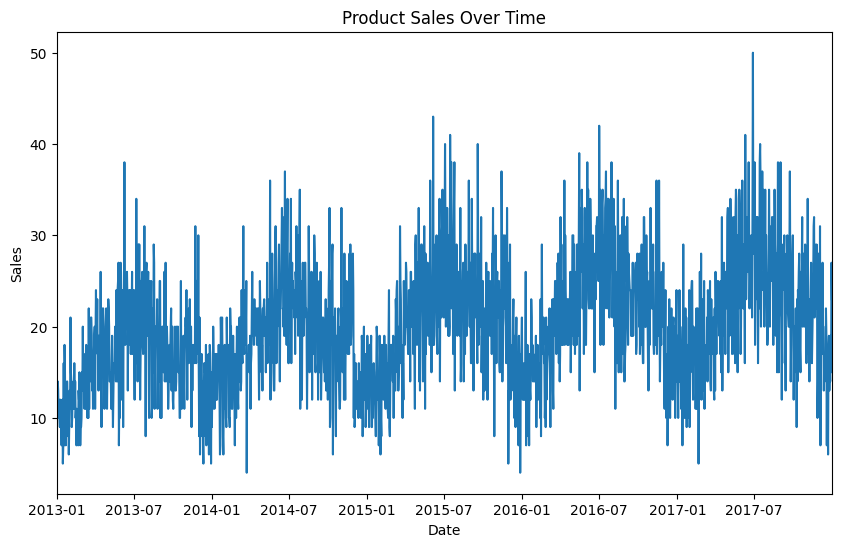

In [85]:
plt.figure(figsize=(10,6))
plt.plot(product_data['sales'])
plt.title('Product Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.margins(x=0)
plt.show()

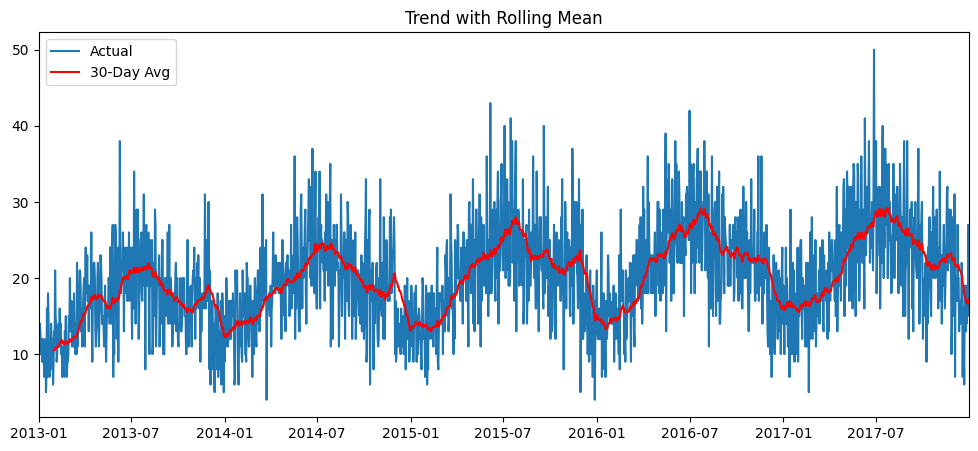

In [89]:
product_data['rolling_mean'] = product_data['sales'].rolling(window=30).mean()

plt.figure(figsize=(12,5))
plt.plot(product_data['sales'], label='Actual')
plt.plot(product_data['rolling_mean'], label='30-Day Avg', color='red')
plt.legend()
plt.title('Trend with Rolling Mean')
plt.margins(x=0)
plt.show()

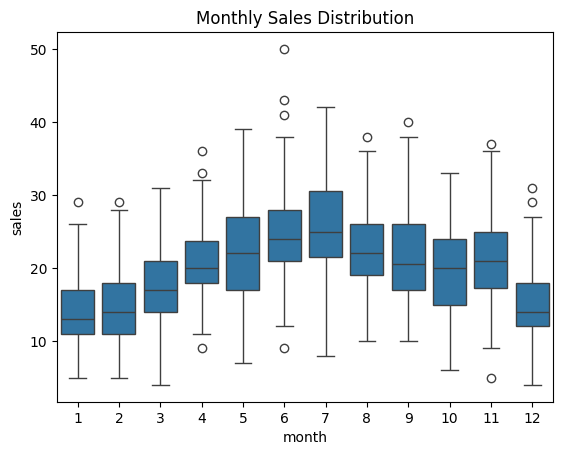

In [90]:
product_data['month'] = product_data.index.month

import seaborn as sns

sns.boxplot(x='month', y='sales', data=product_data)
plt.title('Monthly Sales Distribution')
plt.show()

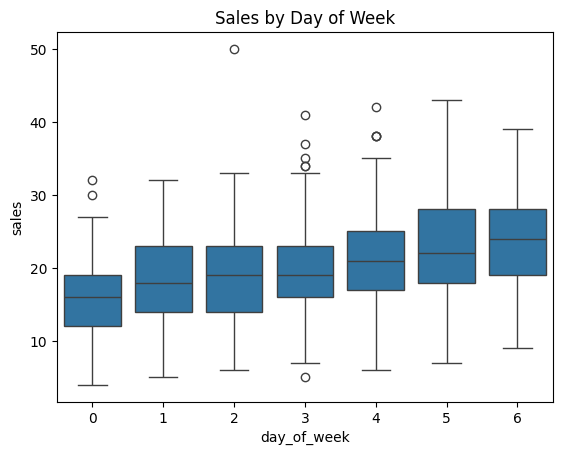

In [91]:
product_data['day_of_week'] = product_data.index.dayofweek

sns.boxplot(x='day_of_week', y='sales', data=product_data)
plt.title('Sales by Day of Week')
plt.show()

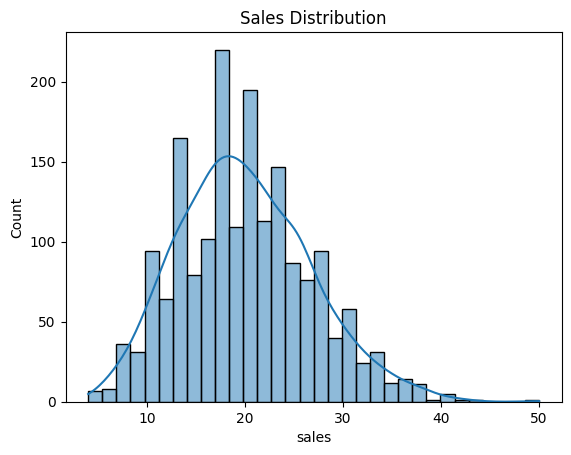

In [92]:
sns.histplot(product_data['sales'], kde=True)
plt.title('Sales Distribution')
plt.show()

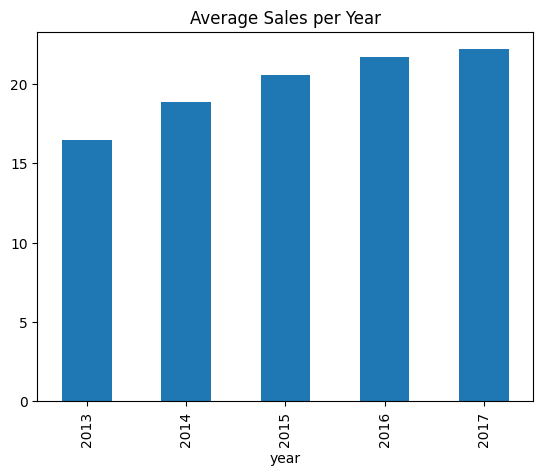

In [93]:
product_data['year'] = product_data.index.year

yearly_sales = product_data.groupby('year')['sales'].mean()

yearly_sales.plot(kind='bar')
plt.title('Average Sales per Year')
plt.show()

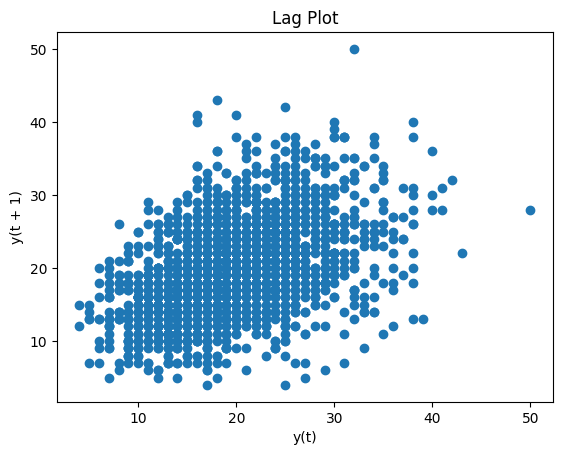

In [94]:
from pandas.plotting import lag_plot

lag_plot(product_data['sales'])
plt.title('Lag Plot')
plt.show()

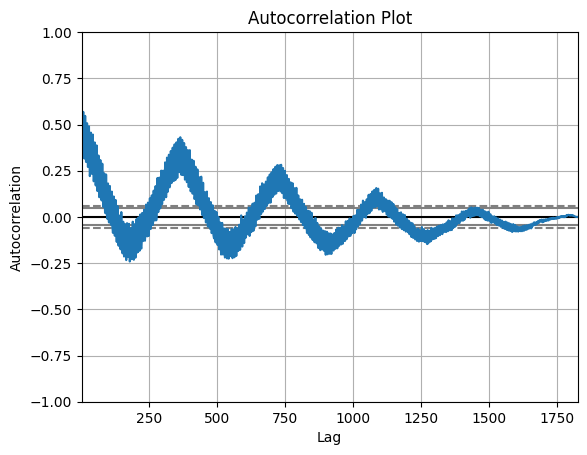

In [95]:
from pandas.plotting import autocorrelation_plot

autocorrelation_plot(product_data['sales'])
plt.title('Autocorrelation Plot')
plt.show()

train-test split

In [96]:
train_data = product_data[:-90]
test_data = product_data[-90:]

MODEL 1: Seasonal Naive

In [97]:
season_length = 7   # weekly seasonality

In [102]:

forecast = []

for i in range(len(test_data)):
    forecast.append(train_data['sales'].iloc[-season_length + (i % season_length)])

test_data = test_data.copy()  
test_data['forecast'] = forecast

In [107]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_sn = mean_absolute_error(test_data['sales'], test_data['seasonal_naive'])
rmse_sn = np.sqrt(mean_squared_error(test_data['sales'], test_data['seasonal_naive']))

print("Seasonal Naive MAE:", mae_sn)
print("Seasonal Naive RMSE:", rmse_sn)

Seasonal Naive MAE: 6.455555555555556
Seasonal Naive RMSE: 7.756717518813397


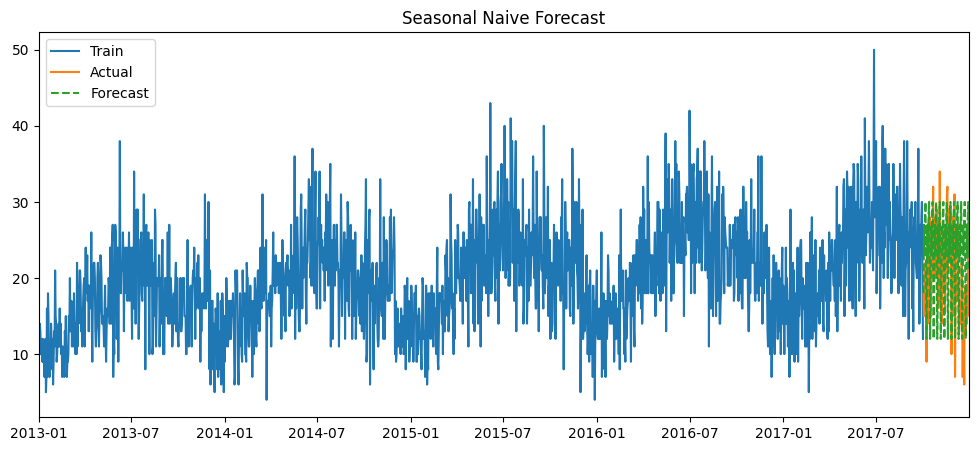

In [108]:
plt.figure(figsize=(12,5))

plt.plot(train_data['sales'], label='Train')
plt.plot(test_data['sales'], label='Actual')
plt.plot(test_data['forecast'], label='Forecast', linestyle='--')

plt.legend()
plt.title('Seasonal Naive Forecast')
plt.margins(x=0)

plt.show()

MODEL 2: Linear Regression

In [109]:
df_lr = product_data.copy()

df_lr['lag1'] = df_lr['sales'].shift(1)
df_lr['lag2'] = df_lr['sales'].shift(2)
df_lr['lag3'] = df_lr['sales'].shift(3)

df_lr = df_lr.dropna()

In [110]:
train_lr = df_lr[:-90]
test_lr = df_lr[-90:]

In [111]:
from sklearn.linear_model import LinearRegression

X_train = train_lr[['lag1','lag2','lag3']]
y_train = train_lr['sales']

X_test = test_lr[['lag1','lag2','lag3']]
y_test = test_lr['sales']

model = LinearRegression()
model.fit(X_train, y_train)

test_lr['lr_pred'] = model.predict(X_test)

In [112]:
mae_lr = mean_absolute_error(y_test, test_lr['lr_pred'])
rmse_lr = np.sqrt(mean_squared_error(y_test, test_lr['lr_pred']))

print("Linear Regression MAE:", mae_lr)
print("Linear Regression RMSE:", rmse_lr)

Linear Regression MAE: 29.80580696820167
Linear Regression RMSE: 38.65612877694554


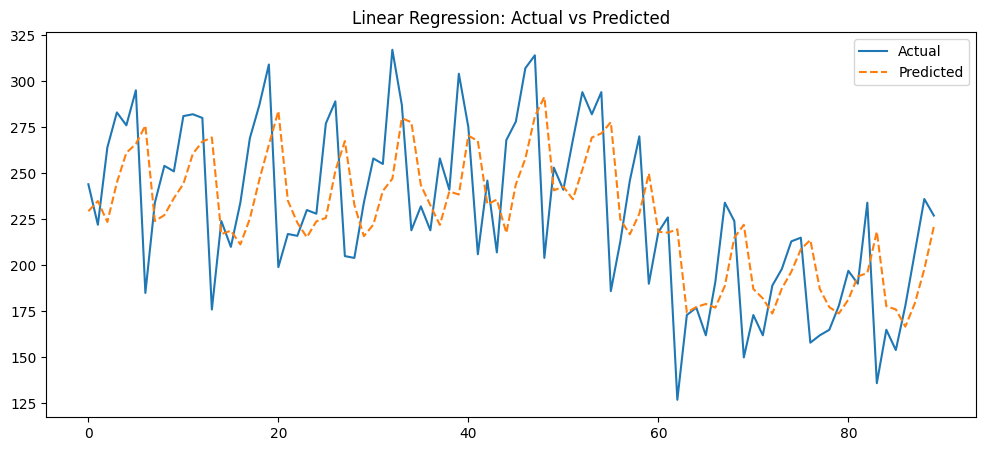

In [113]:
plt.figure(figsize=(12,5))

plt.plot(y_test.values, label='Actual')
plt.plot(test_lr['lr_pred'].values, label='Predicted', linestyle='--')

plt.legend()
plt.title('Linear Regression: Actual vs Predicted')
plt.show()

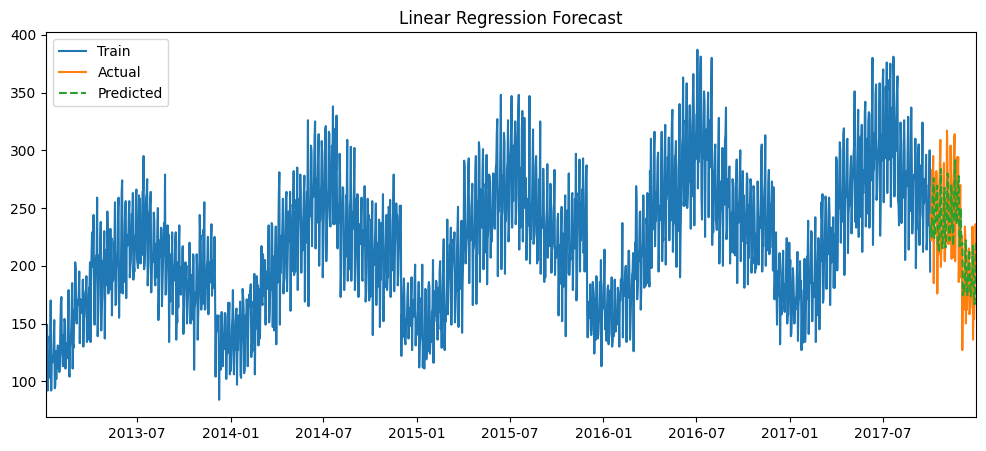

In [114]:
plt.figure(figsize=(12,5))

plt.plot(train_lr.index, train_lr['sales'], label='Train')
plt.plot(test_lr.index, y_test, label='Actual')
plt.plot(test_lr.index, test_lr['lr_pred'], label='Predicted', linestyle='--')

plt.legend()
plt.title('Linear Regression Forecast')
plt.margins(x=0)
plt.show()

MODEL 3: Holt (Exponential Smoothing)

In [119]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

holt_model = ExponentialSmoothing(train_data['sales'], trend='add').fit()

holt_pred = holt_model.forecast(len(test_data))

test_data = test_data.copy()
test_data.loc[:, 'holt'] = holt_pred

c:\Users\HP\Desktop\internship\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [120]:
mae_holt = mean_absolute_error(test_data['sales'], test_data['holt'])
rmse_holt = np.sqrt(mean_squared_error(test_data['sales'], test_data['holt']))

print("Holt MAE:", mae_holt)
print("Holt RMSE:", rmse_holt)

Holt MAE: 5.507783636945009
Holt RMSE: 6.7873597490710145


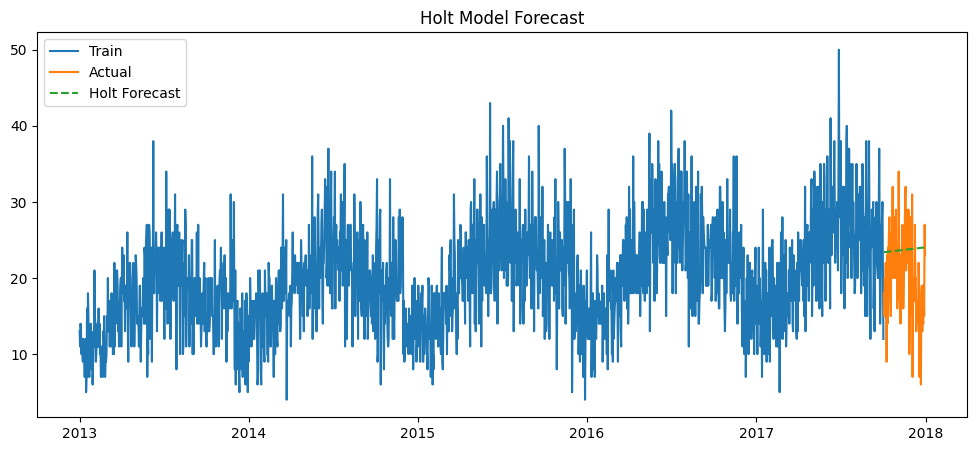

In [121]:
plt.figure(figsize=(12,5))

plt.plot(train_data['sales'], label='Train')
plt.plot(test_data['sales'], label='Actual')
plt.plot(test_data['holt'], label='Holt Forecast', linestyle='--')

plt.legend()
plt.title('Holt Model Forecast')
plt.show()

MODEL 4: ARIMA

In [123]:
from statsmodels.tsa.arima.model import ARIMA

train_data = train_data.asfreq('D')
test_data = test_data.asfreq('D')

arima_model = ARIMA(train_data['sales'], order=(5,1,0))
arima_fit = arima_model.fit()

arima_pred = arima_fit.forecast(steps=len(test_data))

test_data = test_data.copy()
test_data['arima'] = arima_pred

In [126]:
mae_arima = mean_absolute_error(test_data['sales'], test_data['arima'])
rmse_arima = np.sqrt(mean_squared_error(test_data['sales'], test_data['arima']))

print(mae_arima, rmse_arima)

4.827012563758263 6.015989263344459


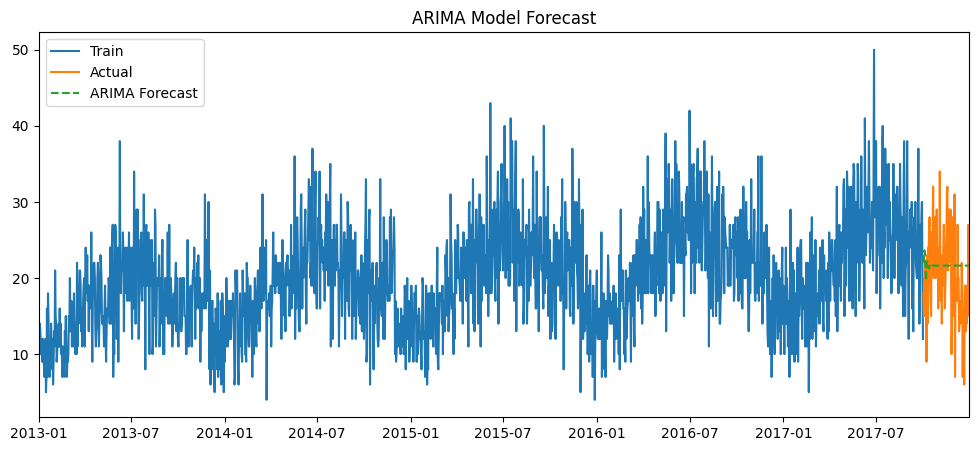

In [127]:
plt.figure(figsize=(12,5))

plt.plot(train_data['sales'], label='Train')
plt.plot(test_data['sales'], label='Actual')
plt.plot(test_data['arima'], label='ARIMA Forecast', linestyle='--')

plt.legend()
plt.title('ARIMA Model Forecast')
plt.margins(x=0)

plt.show()

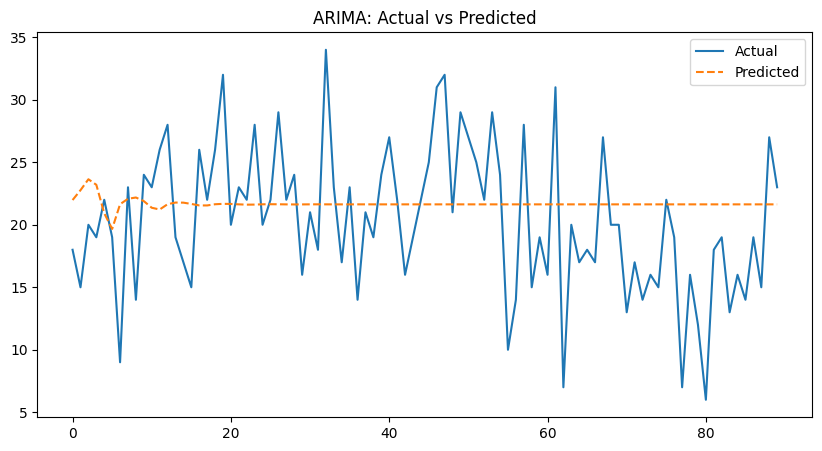

In [128]:
plt.figure(figsize=(10,5))

plt.plot(test_data['sales'].values, label='Actual')
plt.plot(test_data['arima'].values, label='Predicted', linestyle='--')

plt.legend()
plt.title('ARIMA: Actual vs Predicted')
plt.show()

FINAL COMPARISON

In [129]:
results = pd.DataFrame({
    'Model': ['Seasonal Naive', 'Linear Regression', 'Holt', 'ARIMA'],
    'MAE': [mae_sn, mae_lr, mae_holt, mae_arima],
    'RMSE': [rmse_sn, rmse_lr, rmse_holt, rmse_arima]
})

print(results)

               Model        MAE       RMSE
0     Seasonal Naive   6.455556   7.756718
1  Linear Regression  29.805807  38.656129
2               Holt   5.507784   6.787360
3              ARIMA   4.827013   6.015989


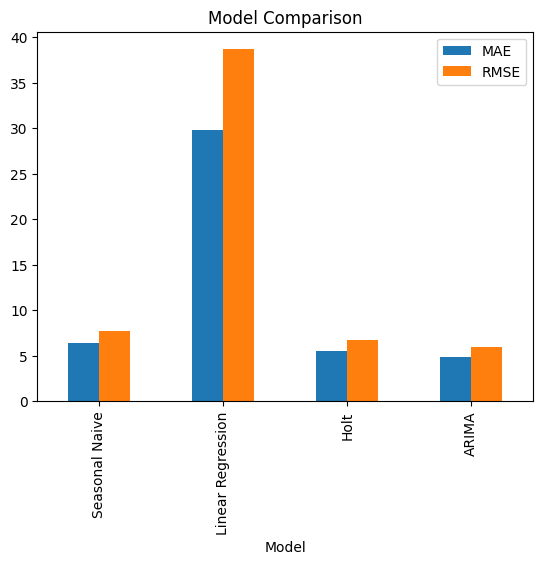

In [130]:
results.set_index('Model').plot(kind='bar')
plt.title('Model Comparison')
plt.show()